# Solutions · Part 1 · Meaning as numbers
Answers to the "Try it" exercises. Each section re-declares what it needs, so it runs on its own.

## Lesson 01
Shared setup from lesson 01: the five recipes, `tokenize`, `keyword_search` and `meaning_search`.

In [1]:
import re

recipes = {
    "Tomato soup": "Simmer tomatoes, onion and garlic, blend until smooth and serve hot with crusty bread.",
    "Mango salsa": "Diced mango, red onion, lime juice and chili. Fresh and zesty, great with tacos.",
    "Chocolate brownies": "Rich fudgy squares of chocolate baked in a tray.",
    "Caesar salad": "Crisp romaine lettuce, croutons, parmesan and a creamy dressing.",
    "Lemon sorbet": "Frozen lemon dessert, sharp and refreshing on summer afternoons.",
}
STOP_WORDS = {"a", "an", "and", "the", "for", "of", "on", "in", "with", "until", "great"}

def tokenize(text):
    return {w for w in re.findall(r"[a-z]+", text.lower()) if w not in STOP_WORDS}

def keyword_search(query, recipes):
    q = tokenize(query)
    scores = {name: len(q & tokenize(text)) for name, text in recipes.items()}
    return sorted(((n, s) for n, s in scores.items() if s > 0), key=lambda item: -item[1])

def meaning_search(query_scores, meaning):
    totals = {name: sum(q * r for q, r in zip(query_scores, scores, strict=True))
              for name, scores in meaning.items()}
    return sorted(totals.items(), key=lambda item: -item[1])

print("setup ready:", len(recipes), "recipes")

setup ready: 5 recipes


**Exercise 1.** Add "Beef stew". Keyword search still finds nothing (no shared words);
meaning search puts the stew near the top, next to Tomato soup.

In [2]:
recipes["Beef stew"] = "Slow-cooked beef, carrots and potatoes in a thick gravy, served steaming."
meaning = {
    "Tomato soup": (0.9, 0.9), "Mango salsa": (0.1, 0.2), "Chocolate brownies": (0.4, 0.8),
    "Caesar salad": (0.1, 0.3), "Lemon sorbet": (0.0, 0.2), "Beef stew": (0.9, 1.0),
}
question = "something warm for a cold day"
print("keyword:", keyword_search(question, recipes) or "no results")
for name, total in meaning_search((1.0, 1.0), meaning)[:3]:
    print(f"{name:20} {total:.2f}")

keyword: no results
Beef stew            1.90
Tomato soup          1.80
Chocolate brownies   1.20


**Exercise 2.** Add a third score, *refreshing*, to every recipe and the query, in the same order
(warm, comforting, refreshing). A query that wants "not warm, refreshing" puts Lemon sorbet first.

In [3]:
meaning3 = {
    "Tomato soup": (0.9, 0.9, 0.1), "Mango salsa": (0.1, 0.2, 0.8),
    "Chocolate brownies": (0.4, 0.8, 0.0), "Caesar salad": (0.1, 0.3, 0.6),
    "Lemon sorbet": (0.0, 0.2, 1.0), "Beef stew": (0.9, 1.0, 0.0),
}
query = (0.0, 0.2, 1.0)  # "a refreshing treat for a summer afternoon"
for name, total in meaning_search(query, meaning3)[:3]:
    print(f"{name:20} {total:.2f}")

Lemon sorbet         1.04
Mango salsa          0.84
Caesar salad         0.66


## Lesson 02
Shared setup from lesson 02: the five recipes as `[sweet, spicy]` vectors, plus the 3-D version
with lesson 01's "warm" score.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

FEATURES = ["sweet", "spicy"]
recipe_vectors = {
    "Tomato soup": [0.3, 0.1], "Mango salsa": [0.6, 0.8], "Chocolate brownies": [0.95, 0.0],
    "Caesar salad": [0.1, 0.1], "Lemon sorbet": [0.8, 0.0],
}
FEATURES_3D = ["sweet", "spicy", "warm"]
warm = {"Tomato soup": 0.9, "Mango salsa": 0.1, "Chocolate brownies": 0.4,
        "Caesar salad": 0.1, "Lemon sorbet": 0.0}
names = list(recipe_vectors)
vectors_3d = np.array([recipe_vectors[n] + [warm[n]] for n in names], dtype=np.float32)
print("setup ready:", vectors_3d.shape)

setup ready: (5, 3)


**Exercise 1.** Thai green curry is very spicy and a little sweet. The shape grows to `(6, 2)`,
and on the map the curry's closest neighbour is Mango salsa, the only other spicy dish.

shape: (6, 2)


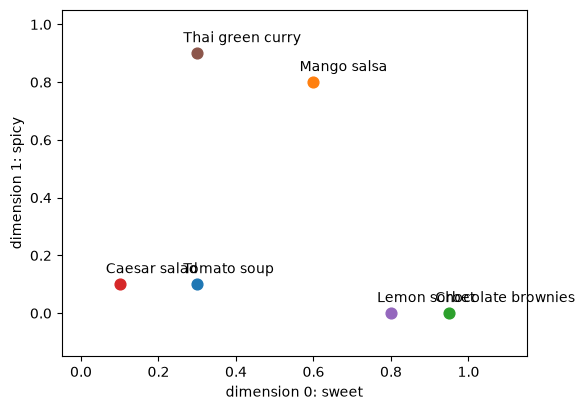

In [5]:
recipe_vectors["Thai green curry"] = [0.3, 0.9]
names = list(recipe_vectors)
vectors = np.array([recipe_vectors[n] for n in names], dtype=np.float32)
print("shape:", vectors.shape)

fig, ax = plt.subplots(figsize=(6, 4.5))
for name, (sweet, spicy) in recipe_vectors.items():
    ax.scatter(sweet, spicy, s=60)
    ax.annotate(name, (sweet, spicy), textcoords="offset points", xytext=(-10, 8))
ax.set_xlabel("dimension 0: sweet")
ax.set_ylabel("dimension 1: spicy")
ax.set_xlim(-0.05, 1.15)
ax.set_ylim(-0.15, 1.05)
plt.show()

**Exercise 2.** Use one column of the 3-D matrix per question (the five original recipes).

In [6]:
names_3d = list(warm)
spicy_col = vectors_3d[:, FEATURES_3D.index("spicy")]
warm_col = vectors_3d[:, FEATURES_3D.index("warm")]
print("spiciest:  ", names_3d[int(np.argmax(spicy_col))])
print("least warm:", names_3d[int(np.argmin(warm_col))])

spiciest:   Mango salsa
least warm: Lemon sorbet


## Lesson 03
Shared setup from lesson 03: the five `[sweet, spicy]` recipes, the 3-D version with "warm",
and one function that ranks the recipes with all three measures.

In [7]:
import numpy as np

FEATURES = ["sweet", "spicy"]
recipe_vectors = {
    "Tomato soup": [0.3, 0.1], "Mango salsa": [0.6, 0.8], "Chocolate brownies": [0.95, 0.0],
    "Caesar salad": [0.1, 0.1], "Lemon sorbet": [0.8, 0.0],
}
warm = {"Tomato soup": 0.9, "Mango salsa": 0.1, "Chocolate brownies": 0.4,
        "Caesar salad": 0.1, "Lemon sorbet": 0.0}
names = list(recipe_vectors)
vectors = np.array([recipe_vectors[n] for n in names], dtype=np.float32)
vectors_3d = np.array([recipe_vectors[n] + [warm[n]] for n in names], dtype=np.float32)

def rank_all(matrix, query):
    q = np.array(query, dtype=np.float32)
    dots = matrix @ q
    euclid = np.linalg.norm(matrix - q, axis=1)
    cosines = dots / (np.linalg.norm(matrix, axis=1) * np.linalg.norm(q))
    print("euclidean:", [names[i] for i in np.argsort(euclid)[:3]])
    print("dot:      ", [names[i] for i in np.argsort(dots)[::-1][:3]])
    print("cosine:   ", [names[i] for i in np.argsort(cosines)[::-1][:3]])

print("step 6 query [0.3, 0.4]:")
rank_all(vectors, [0.3, 0.4])

step 6 query [0.3, 0.4]:
euclidean: ['Tomato soup', 'Caesar salad', 'Mango salsa']
dot:       ['Mango salsa', 'Chocolate brownies', 'Lemon sorbet']
cosine:    ['Mango salsa', 'Caesar salad', 'Tomato soup']


**Exercise 1.** Doubling the query to `[0.6, 0.8]` changes only the **Euclidean** ranking:
the query now sits exactly on Mango salsa (distance 0), so salsa jumps to first.
Cosine ignores length, so it cannot change. The dot product of every recipe is simply doubled,
so its order stays the same too.

In [8]:
print("doubled query [0.6, 0.8]:")
rank_all(vectors, [0.6, 0.8])

doubled query [0.6, 0.8]:
euclidean: ['Mango salsa', 'Tomato soup', 'Lemon sorbet']
dot:       ['Mango salsa', 'Chocolate brownies', 'Lemon sorbet']
cosine:    ['Mango salsa', 'Caesar salad', 'Tomato soup']


**Exercise 2.** With warmth added, Tomato soup is the only recipe that is both warm and
a little sweet, so all three measures now put it first. A dimension that separates the recipes
well makes the measures agree more often.

In [9]:
print("3-D query [0.3, 0.4, 0.8]:")
rank_all(vectors_3d, [0.3, 0.4, 0.8])

3-D query [0.3, 0.4, 0.8]:
euclidean: ['Tomato soup', 'Caesar salad', 'Mango salsa']
dot:       ['Tomato soup', 'Chocolate brownies', 'Mango salsa']
cosine:    ['Tomato soup', 'Caesar salad', 'Chocolate brownies']


## Lesson 04
Shared setup from lesson 04: the five recipes, the 100,000 random recipes, `top_k_smallest`
and the final `knn`.

In [10]:
import numpy as np

recipe_vectors = {
    "Tomato soup": [0.3, 0.1], "Mango salsa": [0.6, 0.8], "Chocolate brownies": [0.95, 0.0],
    "Caesar salad": [0.1, 0.1], "Lemon sorbet": [0.8, 0.0],
}
names = list(recipe_vectors)
vectors = np.array([recipe_vectors[n] for n in names], dtype=np.float32)
big = np.random.default_rng(4).random((100_000, 2), dtype=np.float32)

def top_k_smallest(scores, k):
    k = min(k, len(scores))
    part = np.argpartition(scores, k - 1)[:k]
    return part[np.argsort(scores[part], kind="stable")]

def knn(query, vectors, k, metric="euclidean"):
    q = np.asarray(query, dtype=np.float32)
    if metric == "euclidean":
        scores = np.linalg.norm(vectors - q, axis=1)
        rows = top_k_smallest(scores, k)
    elif metric in ("dot", "cosine"):
        scores = vectors @ q
        if metric == "cosine":
            scores = scores / (np.linalg.norm(vectors, axis=1) * np.linalg.norm(q))
        rows = top_k_smallest(-scores, k)
    else:
        raise ValueError(f"unknown metric {metric!r}")
    return rows, scores[rows]

print("setup ready:", vectors.shape, big.shape)

setup ready: (5, 2) (100000, 2)


**Exercise 1.** Euclidean picks Chocolate brownies (0.95 sweet is nearest to 1.0) then Lemon
sorbet. Cosine gives both a perfect 1.000, because both point straight along "sweet"; it cannot
tell them apart, so their order inside the tie is arbitrary. On the big matrix the five
nearest random recipes all sit very close to the corner `[1, 0]`.

In [11]:
sweet = [1.0, 0.0]
for metric in ["euclidean", "cosine"]:
    rows, scores = knn(sweet, vectors, k=2, metric=metric)
    print(f"{metric:9}:", [(names[i], round(float(s), 3)) for i, s in zip(rows, scores)])

rows, scores = knn(sweet, big, k=5)
for i, s in zip(rows, scores):
    print(f"recipe {i:6}  {np.round(big[i], 3)}  distance {s:.4f}")

euclidean: [('Chocolate brownies', 0.05), ('Lemon sorbet', 0.2)]
cosine   : [('Chocolate brownies', 1.0), ('Lemon sorbet', 1.0)]
recipe  41618  [0.998 0.005]  distance 0.0050
recipe  87700  [0.994 0.   ]  distance 0.0057
recipe  67163  [0.994 0.001]  distance 0.0058
recipe  63497  [0.993 0.002]  distance 0.0067
recipe  79397  [1.    0.007]  distance 0.0073


**Exercise 2.** `queries @ vectors.T` gives an `(m, N)` matrix of dot products: row j holds every
recipe's score for query j. Partition each row (largest first, so negate), then sort the k
selected columns of each row.

In [12]:
def knn_batch(queries, vectors, k):
    scores = np.asarray(queries, dtype=np.float32) @ vectors.T          # (m, N)
    k = min(k, vectors.shape[0])
    part = np.argpartition(-scores, k - 1, axis=1)[:, :k]              # (m, k), unordered
    part_scores = np.take_along_axis(scores, part, axis=1)
    order = np.argsort(-part_scores, axis=1, kind="stable")
    return np.take_along_axis(part, order, axis=1)

queries = np.array([[0.3, 0.4], [0.0, 1.0], [1.0, 0.0]], dtype=np.float32)
batch = knn_batch(queries, vectors, k=3)
one_by_one = np.array([knn(qv, vectors, k=3, metric="dot")[0] for qv in queries])
print(batch)
print("matches one query at a time:", np.array_equal(batch, one_by_one))

[[1 2 4]
 [1 0 3]
 [2 4 1]]
matches one query at a time: True


## Lesson 05
Shared setup from lesson 05: the 50 recipes, the saved MiniLM and bge-small embeddings, and
lesson 04's `knn` (re-declared above for lesson 04, unchanged).

In [13]:
import pandas as pd

recipes = pd.read_csv("../data/recipes_50.csv")
names = recipes["title"].tolist()
minilm = np.load("../data/recipe_embeddings_minilm.npz")["doc_emb"]
bge = np.load("../data/recipe_embeddings_bge-small.npz")["doc_emb"]
print("MiniLM:", minilm.shape, " bge-small:", bge.shape)

MiniLM: (50, 384)  bge-small: (50, 384)


**Exercise 1.** Use Mango salsa's own vector as the query, ask for k + 1 neighbours and drop
its own row (lesson 04, mistake 3). Then count the overlap with a set intersection.
The models agree on two of three (Guacamole and Fish tacos, both Mexican dishes with lime).

In [14]:
def more_like(title, emb, k=3):
    me = names.index(title)
    rows, scores = knn(emb[me], emb, k=k + 1, metric="cosine")
    keep = rows != me
    return [names[i] for i in rows[keep]][:k], np.round(scores[keep][:k], 3)

for label, emb in [("MiniLM", minilm), ("bge-small", bge)]:
    print(f"{label:9}", *more_like("Mango salsa", emb))
agree = set(more_like("Mango salsa", minilm)[0]) & set(more_like("Mango salsa", bge)[0])
print("both models agree on:", sorted(agree))

MiniLM    ['Guacamole', 'Hummus', 'Fish tacos'] [0.7   0.671 0.632]
bge-small ['Guacamole', 'Fish tacos', 'Sushi rolls'] [0.752 0.738 0.712]
both models agree on: ['Fish tacos', 'Guacamole']


**Exercise 2.** One matrix product gives every pair's cosine similarity (unit vectors). Hide the
diagonal, take each row's best score (its nearest neighbour), and pick the row where that best
score is lowest. Tiramisu wins: the only coffee dessert, its best match scores just 0.440.

In [15]:
sims = minilm @ minilm.T                       # (50, 50)
np.fill_diagonal(sims, -1)                     # ignore "similar to itself"
best = sims.max(axis=1)                        # each recipe's nearest-neighbour score
odd = int(np.argmin(best))
print(f"odd one out: {names[odd]}  (nearest is {names[int(sims[odd].argmax())]}, {best[odd]:.3f})")
print(f"best-connected: {names[int(np.argmax(best))]}  ({best.max():.3f})")

odd one out: Tiramisu  (nearest is Pesto pasta, 0.440)
best-connected: Tomato soup  (0.712)


## Lesson 06
Shared setup from lesson 06: the recipes, the saved recipe and query embeddings, and the engine
(`knn` from lesson 04 is re-declared above, unchanged).

In [16]:
recipes = pd.read_csv("../data/recipes_50.csv")
names = recipes["title"].tolist()
doc_emb = np.load("../data/recipe_embeddings_minilm.npz")["doc_emb"]
cache = np.load("../data/query_embeddings_minilm.npz")
query_cache = dict(zip(cache["queries"].tolist(), cache["query_emb"], strict=True))
QUERY_BANK = list(query_cache)

def search(text, k=3, where=None):
    allowed = np.arange(len(names)) if where is None else np.flatnonzero(where)
    rows, scores = knn(query_cache[text], doc_emb[allowed], k=k, metric="dot")
    return [(names[i], round(float(s), 3)) for i, s in zip(allowed[rows], scores, strict=True)]

print("engine ready:", len(names), "recipes,", len(QUERY_BANK), "cached queries")

engine ready: 50 recipes, 15 cached queries


**Exercise 1.** A `minutes <= 30` mask. Strawberry cheesecake (90 min) and Apple pie (75 min) drop
out; Lemon sorbet moves up to first, joined by Panna cotta and Vanilla ice cream. Only Lemon sorbet
is in both pages.

In [17]:
quick = recipes["minutes"] <= 30
print("no filter:     ", search("a fancy dessert for guests"))
print("<= 30 minutes: ", search("a fancy dessert for guests", where=quick))

no filter:      [('Strawberry cheesecake', 0.543), ('Apple pie', 0.512), ('Lemon sorbet', 0.486)]
<= 30 minutes:  [('Lemon sorbet', 0.486), ('Panna cotta', 0.454), ('Vanilla ice cream', 0.449)]


**Exercise 2.** Filter the results by score after ranking. Two queries come back empty:
"something warm for a cold day" and "a chilled drink". The threshold is a blunt tool: it removes
Mango lassi (0.469), a good answer, while keeping Beef stew (0.559) for "quick vegetarian dinner"
and Chocolate chip cookies (0.500) for "a dip for chips". Scores from this model rank well but are not a measure of "correct"
(lesson 05, step 6).

In [18]:
def search_min(text, k=3, where=None, min_score=None):
    results = search(text, k=k, where=where)
    return results if min_score is None else [(t, s) for t, s in results if s >= min_score]

for text in QUERY_BANK:
    page = search_min(text, min_score=0.5)
    print(f"{text:33} {page if page else 'EMPTY'}")

something warm for a cold day     EMPTY
a cold dessert for summer         [('Lemon sorbet', 0.603)]
very spicy food                   [('Spicy tofu stir-fry', 0.634), ('Vindaloo', 0.558), ('Chili con carne', 0.552)]
something to eat in the morning   [('Full English breakfast', 0.593), ('Overnight oats', 0.525)]
quick vegetarian dinner           [('Beef stew', 0.559), ('Full English breakfast', 0.515)]
Italian pasta                     [('Spaghetti carbonara', 0.706), ('Pesto pasta', 0.682), ('Minestrone', 0.633)]
seafood                           [('Grilled salmon', 0.502)]
a chilled drink                   EMPTY
something with chickpeas          [('Falafel wrap', 0.514), ('Hummus', 0.506)]
a fancy dessert for guests        [('Strawberry cheesecake', 0.543), ('Apple pie', 0.512)]
a hot curry                       [('Vindaloo', 0.592)]
healthy salad                     [('Caesar salad', 0.627), ('Greek salad', 0.582), ('Waldorf salad', 0.578)]
comfort food for a rainy evening  [('Chicke